In [2]:
# # 03 - Customer segmentation (K-Means + PCA)
#
# Unsupervised: there is no ground-truth segment column, so evaluation is
# geometry (silhouette) PLUS business judgement. Geometry proposes, judgement
# decides.
#
# **PCA is used for VISUALISATION ONLY.** K-Means is fitted on all 10 scaled
# features. PCA is applied afterwards purely to draw a 2-D picture. It has zero
# effect on the cluster labels - it is a camera, not a filter.

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root :", ROOT)

project root : c:\DS-AI-Spiced\PropheticIQ_AI_Powered_Ecom_Platform


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src.config import RANDOM_SEED
from src.data.prepare import build_customer_frame, build_order_frame
from src.features.build import (
    SEGMENTATION_FEATURES,
    build_segmentation_features,
    prepare_matrix,
)
from src.viz.style import PALETTE, apply_style

apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures" / "segmentation"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FIGURES = True


def show(fig, name):
    if SAVE_FIGURES:
        fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    return fig


print("ready")

ready


In [4]:
# ## Build the feature matrix
#
# All 94,986 customers - segmentation has no outcome to observe, so the
# 180-day churn cohort cutoff does not apply here.

order_frame = build_order_frame()
customer_frame = build_customer_frame(order_frame)
seg = build_segmentation_features(order_frame, customer_frame)

X_raw, X_df = prepare_matrix(seg, SEGMENTATION_FEATURES)
print(f"{X_raw.shape[0]:,} customers x {X_raw.shape[1]} columns "
      f"({len(SEGMENTATION_FEATURES)} features + missing indicators)")
print(seg[SEGMENTATION_FEATURES].describe().T[["mean", "50%", "max"]].round(2).to_string())



94,986 customers x 15 columns (10 features + missing indicators)
                       mean     50%     max
recency_days         239.71  220.41  725.11
n_orders               1.03    1.00   16.00
log_total_revenue      4.49    4.51    9.51
log_avg_order_value    4.47    4.48    9.51
total_items            1.18    1.00   24.00
n_categories           1.00    1.00    5.00
mean_freight_ratio     0.31    0.22    3.00
mean_delivery_days    12.57   10.23  209.63
mean_review_score      4.11    5.00    5.00
mean_installments      2.92    2.00   24.00


In [5]:
# ## Winsorize, then scale
#
# **Why winsorize:** a first run without it put every K>=3 solution's smallest
# cluster at ~0.0% of customers. Extreme outliers (209-day deliveries, 13,440
# BRL orders) were forming singleton clusters and dragging centroids. Clipping
# at the 1st/99th percentile keeps every customer while stopping a handful of
# extremes from defining a "segment" of four people.
#
# **Why scale:** K-Means minimises squared Euclidean distance.
# `total_revenue` spans 0-13,440 and `mean_review_score` spans 1-5. Unscaled,
# revenue would contribute thousands of times more variance and you would be
# clustering on spend alone.

lo = np.nanpercentile(X_raw, 1, axis=0)
hi = np.nanpercentile(X_raw, 99, axis=0)
X_clipped = np.clip(X_raw, lo, hi)

scaler = StandardScaler()
X = scaler.fit_transform(X_clipped)

print(f"clipped {(X_raw != X_clipped).any(axis=1).sum():,} rows on at least one feature")
print(f"scaled: mean ~{X.mean():.2e}, sd ~{X.std():.3f}")

clipped 8,139 rows on at least one feature
scaled: mean ~-5.70e-17, sd ~0.856


In [6]:
# ## Experiment - choose K
#
# Three inputs, not one:
# * **inertia** (elbow) - sum of squared distances to centroids. Always falls
#   as K rises, so it can never pick K alone; look for where improvement slows.
# * **silhouette** - `(b-a)/max(a,b)` per point. Penalises overlap, so unlike
#   inertia it has a real optimum. Computed on a 10k sample because the exact
#   version is O(n^2).
# * **smallest cluster share** - a segment holding 0.1% of customers is not a
#   segment a business can act on.

results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X)
    sil = silhouette_score(X, km.labels_, sample_size=10_000, random_state=RANDOM_SEED)
    sizes = pd.Series(km.labels_).value_counts(normalize=True)
    results.append({"k": k, "inertia": km.inertia_, "silhouette": sil,
                    "smallest_pct": sizes.min() * 100})

k_table = pd.DataFrame(results).set_index("k")
print(k_table.round(4).to_string())

        inertia  silhouette  smallest_pct
k                                        
2   877524.9928      0.1694       45.5225
3   740258.3710      0.1903        3.0341
4   643867.0046      0.2060        1.7213
5   578518.6466      0.1961        1.7213
6   521150.6989      0.2111        1.7213
7   481097.8008      0.2151        1.7213
8   443327.9686      0.2250        1.3507
9   419910.6151      0.1841        1.7213
10  395579.4347      0.1884        1.3455


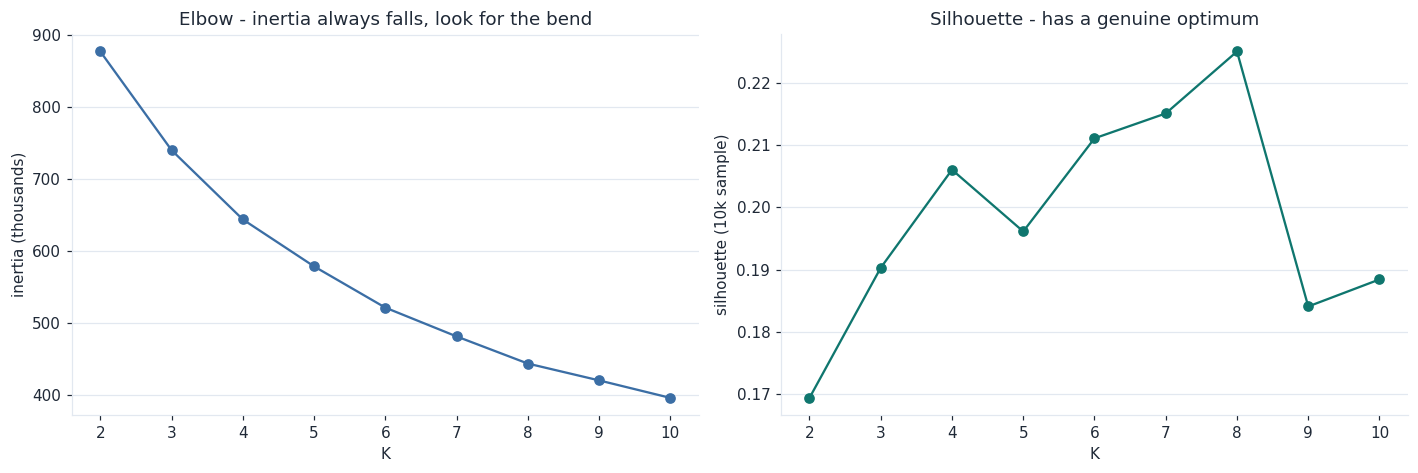

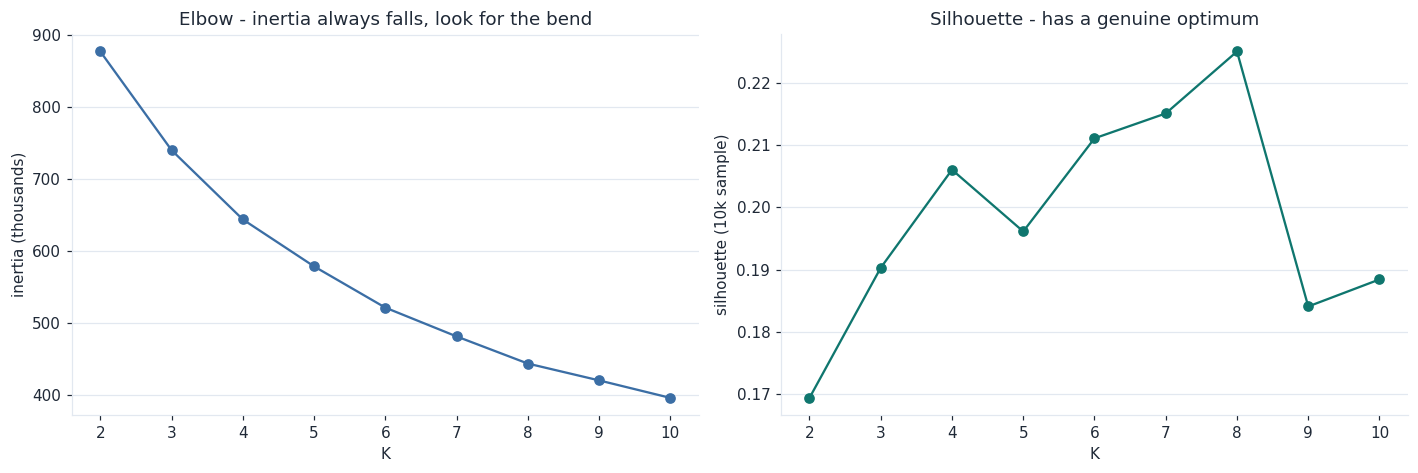

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(k_table.index, k_table["inertia"] / 1e3, marker="o", color=PALETTE[0])
axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia (thousands)")
axes[0].set_title("Elbow - inertia always falls, look for the bend")

axes[1].plot(k_table.index, k_table["silhouette"], marker="o", color=PALETTE[2])
axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette (10k sample)")
axes[1].set_title("Silhouette - has a genuine optimum")
fig.tight_layout()
show(fig, "k_selection")

In [8]:
# ### Choosing K = 6
#
# Silhouette peaks at K=8 (0.225), with K=6 at 0.211 and K=7 at 0.215 - a
# difference of 0.014, well inside noise for a 10k sample. All values sit
# around 0.20, which is **weak, overlapping structure**. That is the honest
# result and it makes sense: 98% of these customers placed exactly one order,
# so there is limited behavioural variety to separate.
#
# Given geometry cannot distinguish 6 / 7 / 8, business usability breaks the
# tie. K=6 produced six groups that map to six different actions. K=8 split two
# of them into near-duplicates. **Report the weak silhouette rather than hiding
# it** - a candidate who says "structure is weak, here is the number" is more
# credible than one claiming clean separation.

K = 6
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X)
seg["cluster"] = kmeans.labels_
print(f"K={K}, silhouette={silhouette_score(X, kmeans.labels_, sample_size=10_000, random_state=RANDOM_SEED):.4f}")
print(seg["cluster"].value_counts(normalize=True).sort_index().mul(100).round(1).to_string())

K=6, silhouette=0.2111
cluster
0    18.8
1    18.5
2     3.0
3    12.3
4     1.7
5    45.7


In [9]:
# ## Cluster profiles
#
# Read the centroids in original units, not scaled ones - "median revenue 239
# BRL" is actionable, "+1.4 standard deviations" is not.

profile = seg.groupby("cluster").agg(
    customers=("customer_unique_id", "size"),
    median_revenue=("total_revenue", "median"),
    median_recency_days=("recency_days", "median"),
    mean_orders=("n_orders", "mean"),
    mean_items=("total_items", "mean"),
    median_freight_ratio=("mean_freight_ratio", "median"),
    median_delivery_days=("mean_delivery_days", "median"),
    mean_review=("mean_review_score", "mean"),
    median_installments=("mean_installments", "median"),
)
profile["pct_customers"] = (profile["customers"] / len(seg) * 100).round(1)
profile["pct_revenue"] = (
    seg.groupby("cluster")["total_revenue"].sum() / seg["total_revenue"].sum() * 100
).round(1)
print(profile.round(2).to_string())

         customers  median_revenue  median_recency_days  mean_orders  mean_items  median_freight_ratio  median_delivery_days  mean_review  median_installments  pct_customers  pct_revenue
cluster                                                                                                                                                                                   
0            17810           25.37               225.38         1.00        1.08                  0.60                 10.10         4.32                  1.0           18.8          3.6
1            17571          239.00               242.66         1.00        1.29                  0.11                 10.52         4.39                  7.0           18.5         45.8
2             2877          181.90               201.61         2.11        2.57                  0.26                 10.98         4.17                  2.5            3.0          5.5
3            11667           99.98               217.49         1

In [10]:
# ## Name the segments
#
# Names are DERIVED FROM THE PROFILE, not hardcoded to cluster ids. K-Means
# label numbering is arbitrary and changes with `n_init` or the seed - an
# earlier version of this script hardcoded a mapping and silently attached
# "low-value" to the highest-spending cluster after a re-fit. Rule-based
# naming cannot drift like that.

def name_segments(profile: pd.DataFrame) -> dict[int, str]:
    """Assign a business label to each cluster from its own statistics."""
    names: dict[int, str] = {}
    remaining = list(profile.index)

    # Never delivered: no delivery date exists at all.
    for c in list(remaining):
        if pd.isna(profile.loc[c, "median_delivery_days"]):
            names[c] = "Never delivered"
            remaining.remove(c)

    # Delivery failures: satisfaction collapsed and delivery is slow.
    for c in list(remaining):
        if profile.loc[c, "mean_review"] < 2.5:
            names[c] = "Delivery failures (at risk)"
            remaining.remove(c)

    # The only genuinely repeat-purchasing group.
    for c in list(remaining):
        if profile.loc[c, "mean_orders"] > 1.5:
            names[c] = "Repeat / multi-item buyers"
            remaining.remove(c)

    # Of what is left: highest spend, highest freight burden, and the rest.
    if remaining:
        hv = profile.loc[remaining, "median_revenue"].idxmax()
        names[hv] = "High-value installment buyers"
        remaining.remove(hv)
    if remaining:
        fb = profile.loc[remaining, "median_freight_ratio"].idxmax()
        names[fb] = "Low-value, freight-burdened"
        remaining.remove(fb)
    for c in remaining:
        names[c] = "Satisfied mainstream"
    return names


SEGMENT_NAMES = name_segments(profile)
seg["segment"] = seg["cluster"].map(SEGMENT_NAMES)

for c in sorted(SEGMENT_NAMES):
    print(f"  cluster {c} -> {SEGMENT_NAMES[c]}")

  cluster 0 -> Low-value, freight-burdened
  cluster 1 -> High-value installment buyers
  cluster 2 -> Repeat / multi-item buyers
  cluster 3 -> Delivery failures (at risk)
  cluster 4 -> Never delivered
  cluster 5 -> Satisfied mainstream


In [11]:
summary = (
    seg.groupby("segment")
    .agg(customers=("customer_unique_id", "size"),
         revenue=("total_revenue", "sum"),
         median_revenue=("total_revenue", "median"),
         mean_review=("mean_review_score", "mean"),
         median_delivery=("mean_delivery_days", "median"),
         median_freight_ratio=("mean_freight_ratio", "median"),
         mean_orders=("n_orders", "mean"))
    .sort_values("revenue", ascending=False)
)
summary["pct_customers"] = (summary["customers"] / len(seg) * 100).round(1)
summary["pct_revenue"] = (summary["revenue"] / summary["revenue"].sum() * 100).round(1)
print()
print(summary.round(2).to_string())


                               customers     revenue  median_revenue  mean_review  median_delivery  median_freight_ratio  mean_orders  pct_customers  pct_revenue
segment                                                                                                                                                          
High-value installment buyers      17571  6176979.08          239.00         4.39            10.52                  0.11         1.00           18.5         45.8
Satisfied mainstream               43426  4216668.62           85.00         4.65             9.00                  0.20         1.00           45.7         31.2
Delivery failures (at risk)        11667  1605321.52           99.98         1.71            21.84                  0.23         1.00           12.3         11.9
Repeat / multi-item buyers          2877   747379.25          181.90         4.17            10.98                  0.26         2.11            3.0          5.5
Low-value, freight-burdened

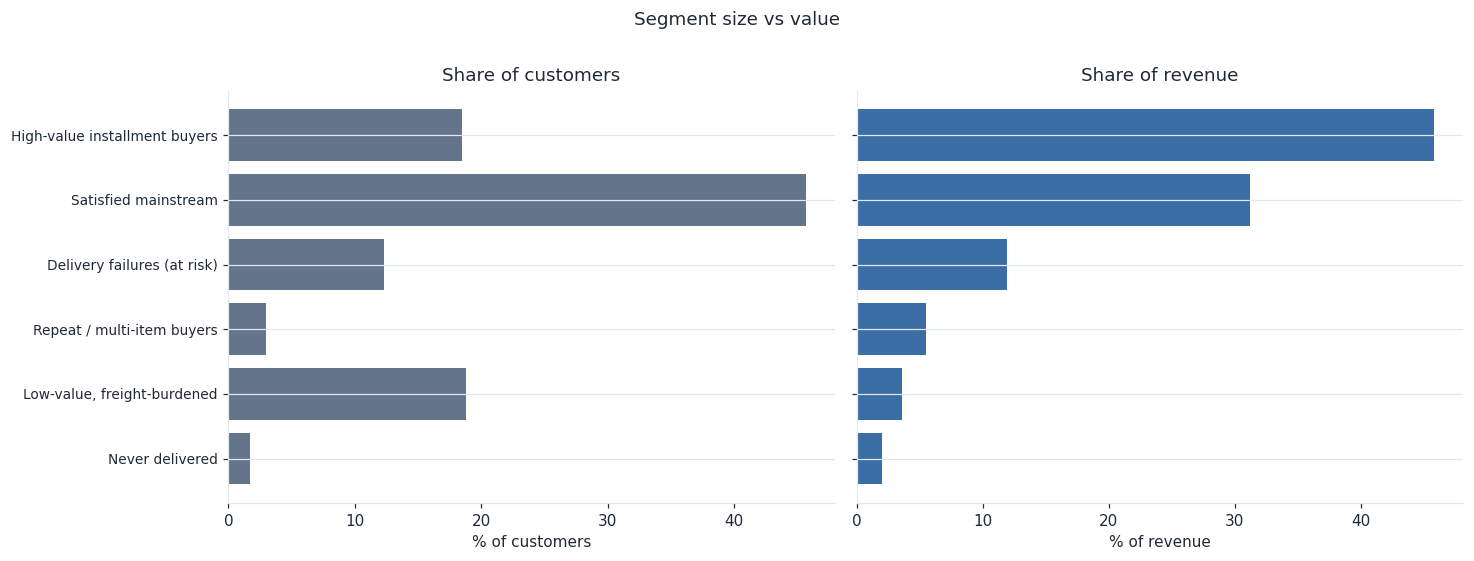

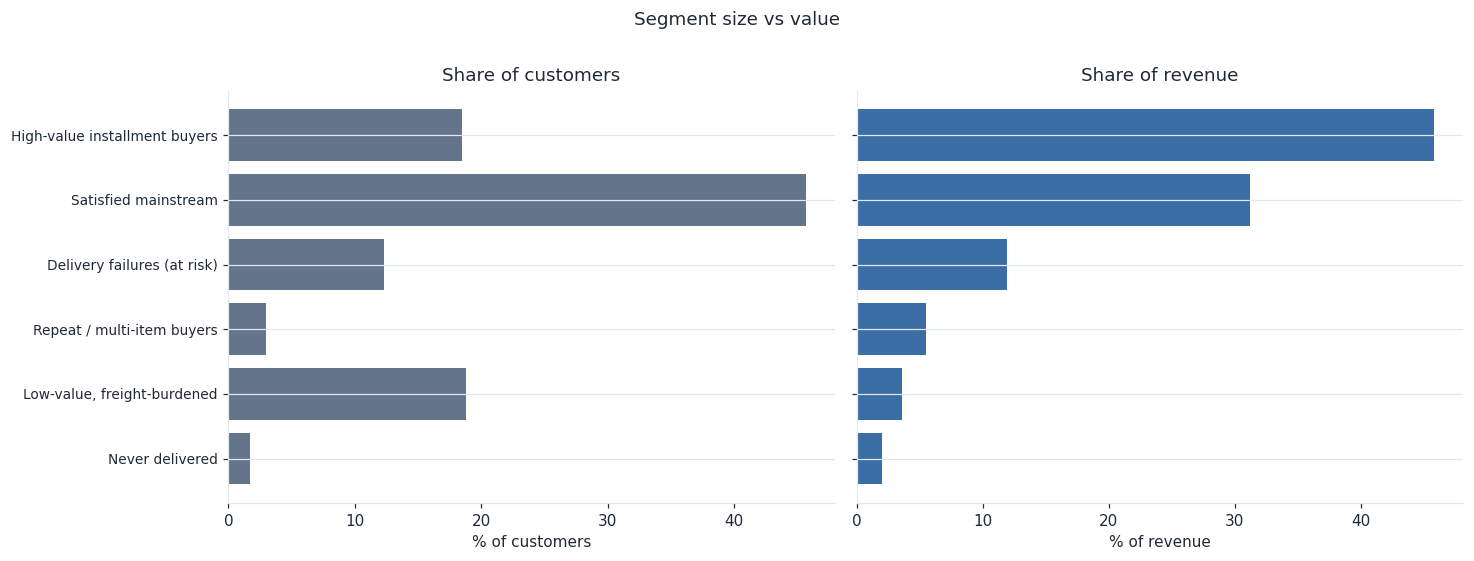

In [12]:
# ## Segment sizes vs revenue contribution

plot_df = summary.sort_values("pct_revenue")
y = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)
axes[0].barh(y, plot_df["pct_customers"], color=PALETTE[5])
axes[0].set_yticks(y, plot_df.index, fontsize=9)
axes[0].set_xlabel("% of customers"); axes[0].set_title("Share of customers")
axes[1].barh(y, plot_df["pct_revenue"], color=PALETTE[0])
axes[1].set_xlabel("% of revenue"); axes[1].set_title("Share of revenue")
fig.suptitle("Segment size vs value", y=1.01)
fig.tight_layout()
show(fig, "segment_value")

PC1 26.0% + PC2 16.5% = 42.5% of variance retained
(the rest is lost - which is why we cluster on the full space, not this)


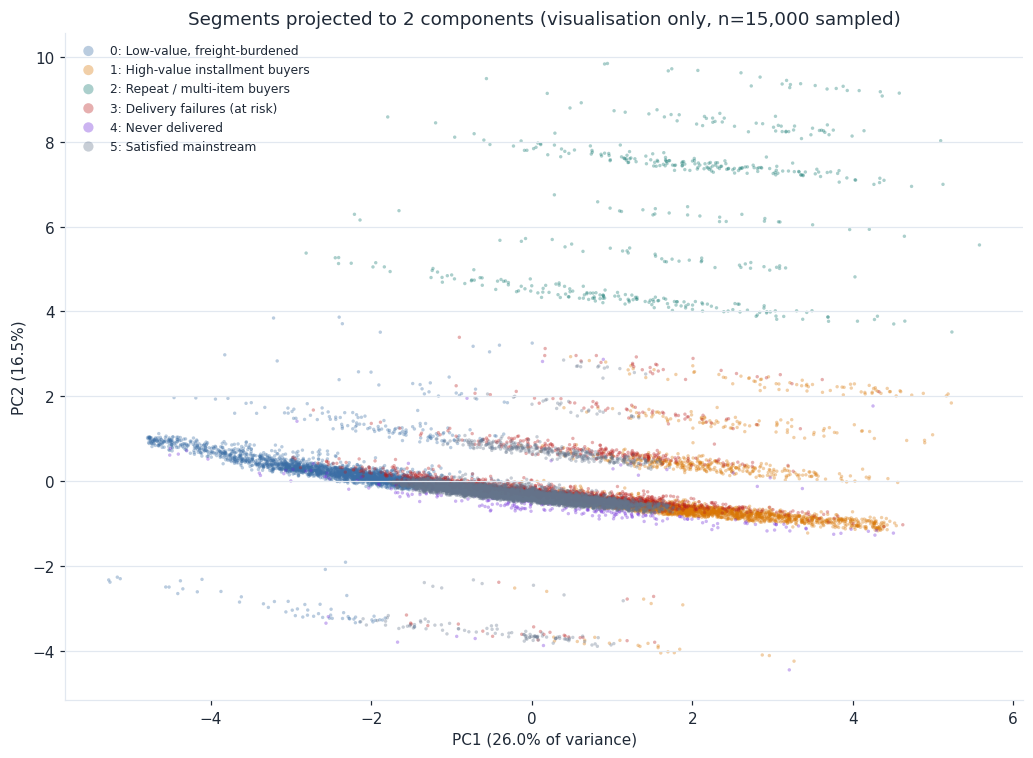

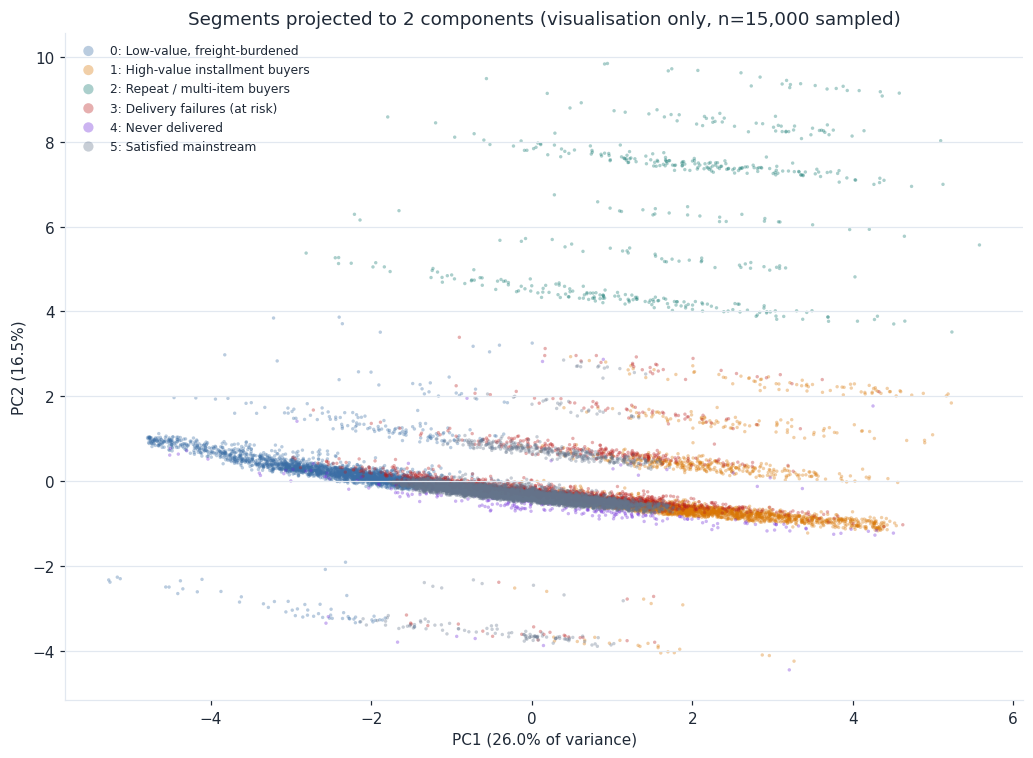

In [13]:
# ## PCA - for visualisation only
#
# Fitted AFTER clustering. The labels below were produced from all 15 scaled
# columns; PCA just projects them onto 2 axes so they can be drawn. Re-running
# K-Means on the components would give different (and worse) clusters - which
# is exactly why we did not do that.

pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X)
var = pca.explained_variance_ratio_
print(f"PC1 {var[0]:.1%} + PC2 {var[1]:.1%} = {var.sum():.1%} of variance retained")
print("(the rest is lost - which is why we cluster on the full space, not this)")

fig, ax = plt.subplots(figsize=(9.5, 7))
sample = np.random.default_rng(RANDOM_SEED).choice(len(coords), 15_000, replace=False)
for c in sorted(seg["cluster"].unique()):
    m = (seg["cluster"].to_numpy()[sample] == c)
    ax.scatter(coords[sample][m, 0], coords[sample][m, 1], s=5, alpha=0.35,
               color=PALETTE[c % len(PALETTE)], edgecolors="none",
               label=f"{c}: {SEGMENT_NAMES[c]}")
ax.set_xlabel(f"PC1 ({var[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1%})")
ax.set_title("Segments projected to 2 components (visualisation only, n=15,000 sampled)")
ax.legend(markerscale=3, fontsize=8, loc="best")
fig.tight_layout()
show(fig, "pca_projection")

In [14]:
# ### What the components mean
#
# PCA loadings tell you which original features each axis is built from.

loadings = pd.DataFrame(
    pca.components_.T, index=X_df.columns, columns=["PC1", "PC2"]
).round(3)
print(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).to_string())

                               PC1    PC2
log_total_revenue            0.573 -0.032
log_avg_order_value          0.564 -0.120
mean_freight_ratio          -0.451  0.200
mean_installments            0.319 -0.050
total_items                  0.156  0.486
n_orders                     0.110  0.625
n_categories                 0.084  0.556
mean_delivery_days           0.045 -0.004
mean_review_score           -0.044 -0.029
mean_delivery_days_missing   0.011 -0.039
recency_days                 0.003 -0.060
log_avg_order_value_missing -0.000 -0.000
mean_freight_ratio_missing  -0.000 -0.000
mean_review_score_missing    0.000 -0.000
mean_installments_missing    0.000 -0.000


In [15]:
# ## DBSCAN comparison (documented, not adopted)
#
# DBSCAN finds arbitrary shapes and labels outliers as noise instead of forcing
# them into a group. It needs `eps` and `min_samples` rather than K. Run on a
# sample because it is memory-heavy at 95k rows.

sub = np.random.default_rng(RANDOM_SEED).choice(len(X), 20_000, replace=False)
for eps in (0.5, 1.0, 1.5, 2.0):
    db = DBSCAN(eps=eps, min_samples=50).fit(X[sub])
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).mean()
    print(f"eps={eps:<4} clusters={n_clusters:<3} noise={noise:.1%}")

eps=0.5  clusters=1   noise=80.0%
eps=1.0  clusters=2   noise=24.0%
eps=1.5  clusters=5   noise=9.5%
eps=2.0  clusters=7   noise=3.8%


In [16]:
# DBSCAN is not adopted here: our clusters differ in *density* as well as
# location, so any single `eps` either merges most customers into one blob or
# labels a large fraction as noise. That is a property of the data, not a bug.

# ## Save

out = seg[["customer_unique_id", "cluster", "segment", "total_revenue",
           "recency_days", "n_orders", "customer_state"]]
out.to_csv(PROCESSED / "customer_segments.csv", index=False)
profile.to_csv(PROCESSED / "segment_profiles.csv")
print(f"saved {len(out):,} customer segment assignments")
print(sorted(p.name for p in PROCESSED.glob("*.csv")))

saved 94,986 customer segment assignments
['aspect_summary.csv', 'churn_model_comparison.csv', 'customer_segments.csv', 'daily_revenue.csv', 'forecast_backtest.csv', 'recommender_comparison.csv', 'revenue_forecast_90d.csv', 'review_model_comparison.csv', 'review_model_validation.csv', 'review_sentiment.csv', 'segment_profiles.csv', 'sentiment_model_comparison.csv']
